Spotify Group Project
# Phase 1
Exploring Research Area A: Curation vs. Consumption 

Explore the gap between what users save to their library and what they actually listen to. What does this gap reveal about user behavior, content discovery, and engagement?

In [1]:
# 1. Set up environment (toml file and .ipnyb file created)
# Installing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import json
import re
from glob import glob
from datetime import datetime
from pandas import json_normalize
from scipy.stats import entropy


## Data Set Up
Look over the relevant files and see previewed data for this user.

### Data loading
Data frame creation

In [2]:
# Looking over all files in the data folder to understand their structure and content
# Loading track metadata for reference (if needed for analysis) - may use this later
track_meta = pd.read_csv("data/track_data.csv")

# YourLibrary file to see what they saved
# Load YourLibrary.json
with open("data/YourLibrary.json", "r", encoding="utf-8") as f:
    yourlibrary_data = json.load(f)

# Wrap in a single-row DataFrame
library_df = pd.DataFrame([yourlibrary_data])

print("YourLibrary (Saved Songs) Preview")
print(library_df.head())
print(library_df.columns)
print("Number of rows in YourLibrary:", len(library_df))

# Check which columns contain lists
for col in library_df.columns:
    if isinstance(library_df[col][0], list):
        print(f"Column '{col}' contains lists of saved items (length {len(library_df[col][0])})")

# Check which columns contain saved music
for col in library_df.columns:
    if library_df[col].apply(lambda x: isinstance(x, list)).any():
        print(f"Column '{col}' contains lists of saved items.")

# Playlist files to see what they saved in playlists
playlist_files = glob("data/Playlist*.json")
playlist_tracks_list = []

for file in playlist_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
    playlists = data.get('playlists', data)  # handle nested or top-level list
    for pl in playlists:
        items = pl.get('items', [])
        for item in items:
            track = item.get('track', {})
            track['playlistName'] = pl.get('name')
            playlist_tracks_list.append(track)

playlist_df = pd.DataFrame(playlist_tracks_list)
playlist_df['saved'] = True

print("\nPlaylist Tracks Preview")
print(playlist_df.head())
print(playlist_df.columns)
print("Number of tracks in playlists:", len(playlist_df))

# Explore playlist names
unique_playlists = playlist_df['playlistName'].unique()
print("\nPlaylist Names:")
for name in unique_playlists:
    print("-", name)

# Number of tracks per playlist
tracks_per_playlist = playlist_df.groupby('playlistName').size().reset_index(name='num_tracks')
print("\nNumber of tracks per playlist:")
print(tracks_per_playlist)

# Streaming history files to see what they played
stream_files = glob("data/StreamingHistory_music_*.json")
history_list = []

for file in stream_files:
    with open(file, "r", encoding="utf-8") as f:
        data = json.load(f)
        history_list.extend(data)

history_df = pd.DataFrame(history_list)
history_df['played'] = True

print("\nStreaming History Preview")
print(history_df.head())
print(history_df.columns)
print("Number of streamed tracks:", len(history_df))

YourLibrary (Saved Songs) Preview
  tracks albums shows episodes bannedTracks artists bannedArtists pageMatch  \
0     []     []    []       []           []      []            []        []   

                                              other  
0  [spotify:local:::Bo+Burnham+-+Kill+Yourself:177]  
Index(['tracks', 'albums', 'shows', 'episodes', 'bannedTracks', 'artists',
       'bannedArtists', 'pageMatch', 'other'],
      dtype='object')
Number of rows in YourLibrary: 1
Column 'tracks' contains lists of saved items (length 0)
Column 'albums' contains lists of saved items (length 0)
Column 'shows' contains lists of saved items (length 0)
Column 'episodes' contains lists of saved items (length 0)
Column 'bannedTracks' contains lists of saved items (length 0)
Column 'artists' contains lists of saved items (length 0)
Column 'bannedArtists' contains lists of saved items (length 0)
Column 'pageMatch' contains lists of saved items (length 0)
Column 'other' contains lists of saved items (le

This user did not have any saved songs (blank YourLibrary file) - however they do have 3 saved playlists, which can act as the "curation" aspect to compare consumption behavior against. Each playlist has <100 songs on each playlist which may provide comparison points for "consumption".

### Text manipulation/Match Keys
Clean up artists, track names, and the match keys.

In [3]:
# Function to clean text for matching
def clean_text(text):
    if pd.isna(text):
        return None
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9 ]", "", text)
    return text

# Clean playlist fields
playlist_df["artist_clean"] = playlist_df["artistName"].apply(clean_text)
playlist_df["track_clean"] = playlist_df["trackName"].apply(clean_text)
playlist_df["match_key"] = playlist_df["artist_clean"] + "_" + playlist_df["track_clean"]

# Clean streaming fields
history_df["artist_clean"] = history_df["artistName"].apply(clean_text)
history_df["track_clean"] = history_df["trackName"].apply(clean_text)
history_df["match_key"] = history_df["artist_clean"] + "_" + history_df["track_clean"]

print("Match keys successfully created.")

Match keys successfully created.


Spotify playlist and streaming history datasets contain track and artist names as raw text fields. Since these fields might contain variations in how they are written, matching can be an issue when doing joins. 

Text preprocessing was applied to both the playlist and streaming history datasets. This included:

- Converting text to lowercase
- Removing punctuation and special characters
- Standardizing whitespace
- Creating a combined match key using artist and track name (cleaned)

### Data handling

Creating merges, and handling missing data.

In [4]:
# Merging on the cleaned match_key to find which playlist tracks were played according to streaming history
playlist_history_df = pd.merge(
    playlist_df,
    history_df[["match_key", "played"]],
    on="match_key",
    how="left",
    indicator=True
)

# Merging tracks to metadata for analysis of characteristics of saved vs streamed tracks
# Playlist tracks metadata
playlist_meta = playlist_df.merge(
    track_meta,
    left_on=['trackName', 'artistName'],
    right_on=['track_name', 'artists'],
    how='left'
)

# Streaming history metadata merge
history_meta = history_df.merge(
    track_meta,
    left_on=['trackName'],
    right_on=['track_name'],
    how='inner'
)



In [5]:
# Quantify missing data
missing_counts = playlist_history_df["_merge"].value_counts()
print("\nMerge Results:")
print(missing_counts)

percent_not_played = (
    (playlist_history_df["_merge"] == "left_only").sum() /
    len(playlist_history_df)
) * 100

print(f"\nPercent of playlist tracks never streamed: {percent_not_played:.2f}%")


Merge Results:
_merge
both          28317
left_only        69
right_only        0
Name: count, dtype: int64

Percent of playlist tracks never streamed: 0.24%


Data Handling

The roadblock in this research area is that saved content (- or saved tracks in playlists) does not always appear in the user's streaming history. This creates structural missing data when joining playlist data with listening history.

To quantify, playlist tracks were merged with streaming history using the constructed match key, with an indicator then used to identify which tracks appeared in both datasets and which appeared only in playlists.

Two cases may emerge (I am setting this up to evaluate for multiple profiles when the time comes for future phases):
 *  Saved and streamed tracks - tracks that appear in both playlists and streaming history. These represent content the user intentionally saved and actively listened to

 * Saved only tracks - tracks that appear in playlists but never appear in streaming history. These tracks represent potential aspirational saves — music the user wanted to listen to but never actually played (can be indicative of behavior as they may prefer some playlists over others or have other listening habits)

Rather than removing these missing values or imputing data, the missingness itself was treated as a behavioral signal -so attempts are made to preserve information about user intent and better indicates real listening behavior.

The proportion of playlist tracks that do not appear in streaming history was calculated to measure the extent of aspirational saving behavior.

Treating missing data as meaningful behavioral information provides insights into how users curate music collections versus how they actually consume music.

## Initial Analysis

In [6]:
# Playlists vs Streaming History

# Calculate the percentage of playlist tracks that were never played
percent_not_played = (
    (playlist_history_df["_merge"] == "left_only").sum() /
    len(playlist_history_df)
) * 100

print(f"\nPercent of playlist tracks never streamed: {percent_not_played:.2f}%")

# Check if a playlist track was played 
playlist_history_df["played_any"] = playlist_history_df["_merge"] == "both"

playlist_history_df["usage_category"] = playlist_history_df["_merge"].map({
    "both": "Saved & Streamed",
    "left_only": "Saved Only"
})

# Group by playlist track to see if it was played at least once
played_unique = playlist_history_df.groupby(['artistName', 'trackName'])['played_any'].any().sum()

# Calculate metrics
total_playlist_tracks = len(playlist_df)
played_from_playlist = playlist_history_df['played'].sum()
library_utilization_rate_unique = played_unique / total_playlist_tracks if total_playlist_tracks > 0 else 0

print(f"Total tracks in playlists: {total_playlist_tracks}")
print(f"Tracks from playlists that were played: {played_unique}")
print(f"Library/Playlist utilization rate (unique tracks): {library_utilization_rate_unique:.2%}")

# Streaming but not in playlist
stream_only = history_df[~history_df["match_key"].isin(playlist_df["match_key"])]

percent_stream_only = (len(stream_only) / len(history_df)) * 100
print(f"Percent of streamed tracks not in playlists: {percent_stream_only:.2f}%")

# ID "aspirational saves" (saved but never played)
aspirational_tracks = playlist_history_df[playlist_history_df['played'] == False]
print(f"\nNumber of aspirational (never played) tracks: {len(aspirational_tracks)}")
print("Sample aspirational tracks:")
print(aspirational_tracks[['artistName', 'trackName', 'playlistName']].head(10))

# ID "hidden favorites" (played often but not in playlists)
# First, make a set of playlist tracks for easy lookup
playlist_track_set = set(zip(playlist_df['artistName'], playlist_df['trackName']))
# Then filter streaming history for tracks not in playlist
history_df['in_playlist'] = history_df.apply(lambda row: (row['artistName'], row['trackName']) in playlist_track_set, axis=1)
hidden_favorites = history_df[(history_df['in_playlist'] == False)]
print(f"\nNumber of hidden favorites (played but not in playlists): {len(hidden_favorites)}")
print("Sample hidden favorites:")
print(hidden_favorites[['artistName', 'trackName', 'msPlayed']].head(10))


Percent of playlist tracks never streamed: 0.24%
Total tracks in playlists: 883
Tracks from playlists that were played: 810
Library/Playlist utilization rate (unique tracks): 91.73%
Percent of streamed tracks not in playlists: 13.26%

Number of aspirational (never played) tracks: 0
Sample aspirational tracks:
Empty DataFrame
Columns: [artistName, trackName, playlistName]
Index: []

Number of hidden favorites (played but not in playlists): 4424
Sample hidden favorites:
                artistName                              trackName  msPlayed
50            XXXTENTACION                            Look At Me!       950
53  A Boogie Wit da Hoodie                Swervin (feat. 6ix9ine)       580
56            XXXTENTACION                            Look At Me!       540
63                Votabias                           Gang With Me       690
64                  Eminem  Venom - Music From The Motion Picture      1470
65        Childish Gambino                        This Is America     

The analysis compared tracks saved in playlists with tracks appearing in the user's streaming history in order to understand the relationship between curation behavior (saving tracks) and actual listening behavior.

### Playlist Utilization

The results show a  strong overlap between saved playlist content and listening activity. Out of 883 total playlist tracks, 810 were found in the streaming history, resulting in a playlist utilization rate of 91.73%, with only 0.24% of playlist tracks were never being streamed.

This may suggest that playlists for this user are not primarily aspirational collections but rather reflect music that the user actively listens to. In other words, playlist curation appears to be reflective of actual consumption behavior.

### Aspirational Saves

Aspirational saves are tracks that a user saves but never ends up listening to. In this dataset, no aspirational tracks were identified, meaning that every saved track appeared at least once in the streaming history. This indicates that this particular user tends to save music after discovering or listening to it, rather than saving music with the intention of listening later.

This suggests that playlists function primarily as an organizational tool for frequently played music rather than a backlog - however this metric is important to note for future phases to compare other users' listening behaviors.

### Hidden Favorites

While most playlist tracks were streamed, the analysis also identified a large number of "hidden favorites" — tracks that appear frequently in streaming history but are not saved in any playlist.

A total of 4,424 tracks were streamed but never added to playlists, representing 13.26% of streamed tracks. These tracks may represent more implicit preferences like:
 * Music discovered through algorithmic recommendations (which could result from the algorithm playing similar styles of music once the playlist is played through in full)
 * Casual listening
 * Tracks played through radio, autoplay, or curated mixes
 * Music the user enjoys but has not formally organized into playlists

Some examples of hidden favorites include artists such as XXXTENTACION, Eminem, Childish Gambino, and StaySolidRocky, who shows up in streaming history although not shown in curation behavior.

### Behavioral Indication

Together, these findings may suggest that the user demonstrates listening behaviors:
 * Curated listening — music intentionally saved and organized into playlists, which correlates with actual listening behavior
 * Exploratory listening — music that appears in the streaming history but is not saved, indicating discovery through Spotify’s recommendation algorithm

Understanding the difference between curated and exploratory listening could help improve recommendation algorithms by identifying which tracks users value enough to save vs those they might only engage with temporarily.

In [7]:
# Track Metadata Analysis with consumption and curation

# Playlist Metadata Summary
print("Playlist Metadata Summary")
print(f"Number of playlist tracks with metadata: {len(playlist_meta)}")
print("\nTop Genres in Playlists:")
print(playlist_meta['track_genre'].value_counts().head(10))
print("\nAverage Track Features for Playlist Tracks:")
print("Popularity:", round(playlist_meta['popularity'].mean(), 2))
print("Danceability:", round(playlist_meta['danceability'].mean(), 2))
print("Valence (positivity):", round(playlist_meta['valence'].mean(), 2))
print("Energy:", round(playlist_meta['energy'].mean(), 2))
print("Acousticness:", round(playlist_meta['acousticness'].mean(), 2))

# Sample of playlist tracks with metadata
print("\nSample Playlist Tracks with Metadata:")
print(playlist_meta[['artistName', 'trackName', 'track_genre', 'popularity', 'danceability', 'valence']].head(10))

# Streaming History Metadata Summary
print("\nStreaming History Metadata Summary")
print(f"Number of streamed tracks with metadata: {len(history_meta)}")
print("\nTop Genres in Streaming History:")
print(history_meta['track_genre'].value_counts().head(10))
print("\nAverage Track Features for Streamed Tracks:")
print("Popularity:", round(history_meta['popularity'].mean(), 2))
print("Danceability:", round(history_meta['danceability'].mean(), 2))
print("Valence (positivity):", round(history_meta['valence'].mean(), 2))
print("Energy:", round(history_meta['energy'].mean(), 2))
print("Acousticness:", round(history_meta['acousticness'].mean(), 2))

# Sample of streamed tracks with metadata
print("\nSample Streamed Tracks with Metadata:")
print(history_meta[['artistName', 'trackName', 'track_genre', 'popularity', 'danceability', 'valence']].head(10))

Playlist Metadata Summary
Number of playlist tracks with metadata: 1092

Top Genres in Playlists:
track_genre
emo         13
pop-film    13
dance       11
rock        10
alt-rock     8
hip-hop      6
piano        6
pop          5
electro      4
folk         2
Name: count, dtype: int64

Average Track Features for Playlist Tracks:
Popularity: 62.76
Danceability: 0.68
Valence (positivity): 0.5
Energy: 0.65
Acousticness: 0.18

Sample Playlist Tracks with Metadata:
          artistName                                          trackName  \
0             Pritam                                          Tum Se Hi   
1       Arijit Singh  Bekhayali (Arijit Singh Version) [From "Kabir ...   
2      Jeet Gannguli                                        Khamoshiyan   
3             Pritam                                             Raabta   
4             Pritam                                              Ilahi   
5  Yo Yo Honey Singh                                          Blue Eyes   
6     Moha

This exploration was done out of curiosity to see this user's tastes. Clearly, we are missing some metadata from songs that exist in this user's playlists/streaming history, which can be remedied later if additional insights are needed.

In terms of playlists:
* Tracks with metadata: 1,092
* Top genres: Emo, pop-film, dance, rock, alt-rock

Average features:
* Popularity: 62.76
* Danceability: 0.68
* Valence: 0.5 (neutral)
* Energy: 0.65
* Acousticness: 0.18

Playlists contain slightly less popular and higher-energy tracks compared to what was actually streamed.

In terms of streaming history:
* Tracks with metadata: 74,624
* Top genres: Pop-film, emo, indian, sad, hip-hop

Average features:
* Popularity: 52.01
* Danceability: 0.63
* Valence: 0.44 (more “sad/serious” tracks)
* Energy: 0.62
* Acousticness: 0.26

Users streamed a broader set of tracks than what is represented in playlists (to be expected). Streams are slightly more popular overall and slightly more danceable, but lower in energy and valence, suggesting the streamed content is somewhat different from what users curated.

## Visualizations
### Figure 1.1

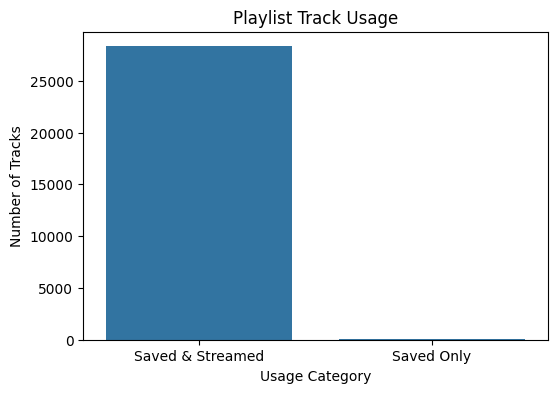

In [8]:
# Count usage categories
usage_counts = playlist_history_df["usage_category"].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=usage_counts.index, y=usage_counts.values)

plt.title("Playlist Track Usage")
plt.xlabel("Usage Category")
plt.ylabel("Number of Tracks")

plt.show()

This visualizes how playlist tracks are actually used (listened to) in comparison to those that are curated but not consumed.

### Figure 1.2

Playlist Genre Diversity (Entropy): 2.622
Streaming Genre Diversity (Entropy): 4.083


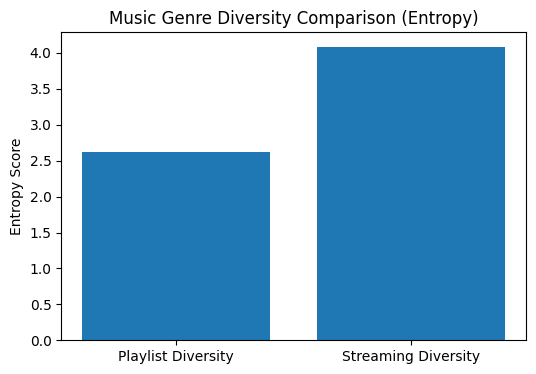

In [9]:
# Analyze genre diversity using Shannon entropy
# Remove missing genres
playlist_genres = playlist_meta['track_genre'].dropna()
stream_genres = history_meta['track_genre'].dropna()

# Genre distributions
playlist_genre_dist = playlist_genres.value_counts(normalize=True)
stream_genre_dist = stream_genres.value_counts(normalize=True)

# Calculate Shannon entropy
playlist_entropy = entropy(playlist_genre_dist)
stream_entropy = entropy(stream_genre_dist)

print("Playlist Genre Diversity (Entropy):", round(playlist_entropy,3))
print("Streaming Genre Diversity (Entropy):", round(stream_entropy,3))

# Visualization
entropy_values = [playlist_entropy, stream_entropy]
labels = ["Playlist Diversity", "Streaming Diversity"]

plt.figure(figsize=(6,4))
plt.bar(labels, entropy_values)

plt.title("Music Genre Diversity Comparison (Entropy)")
plt.ylabel("Entropy Score")

plt.show()

To compare how diverse the music is in playlists vs streaming history (curation vs consumption), Shannon entropy was used. Entropy is a way to measure how spread out something is across categories (music genres). A higher score means the music is spread across more genres, while lower score means that music is concentrated in fewer genres.

 * Playlist Genre Diversity (Entropy): 2.622
 * Streaming Genre Diversity (Entropy): 4.083

The streaming history has a much higher entropy score, which means the user listens to a wider variety of genres while streaming compared to what they save in playlists.

This suggests that playlists tend to contain a smaller, more focused set of favorite genres, while streaming behavior includes more exploration and variety. In other words, playlists may represent the user's core music taste, while streaming history shows the broader range of music they try out or discover. Something to note is that this could be a result of either the user seeking out new music on their own, or letting the algorithm push their recommendations to them passively.